In [1]:
from IPython.display import HTML
HTML('''
    <style> body {font-family: "Roboto Condensed Light", "Roboto Condensed";} h2 {padding: 10px 12px; background-color: #E64626; position: static; color: #ffffff; font-size: 40px;} .text_cell_render p { font-size: 15px; } .text_cell_render h1 { font-size: 30px; } h1 {padding: 10px 12px; background-color: #E64626; color: #ffffff; font-size: 40px;} .text_cell_render h3 { padding: 10px 12px; background-color: #0148A4; position: static; color: #ffffff; font-size: 20px;} h4:before{ 
    content: "@"; font-family:"Wingdings"; font-style:regular; margin-right: 4px;} .text_cell_render h4 {padding: 8px; font-family: "Roboto Condensed Light"; position: static; font-style: italic; background-color: #FFB800; color: #ffffff; font-size: 18px; text-align: center; border-radius: 5px;}input[type=submit] {background-color: #E64626; border: solid; border-color: #734036; color: white; padding: 8px 16px; text-decoration: none; margin: 4px 2px; cursor: pointer; border-radius: 20px;}</style>
''')

# Consumer Price Index (CPI) Time Series Forecast 

### _Background and Problem Formulation_

- **What is CPI?** The Consumer Price Index (CPI) measures household inflation and includes statistics about price change for categories of household expenditure (ABS, 2025). 
- **Business Context:** Forecasting CPI helps policymakers, economists, and businesses make informed decisions regarding inflation, budgeting, and economic planning.
- **Task Definition:** Using historical CPI data (1995-Q1 to 2022-Q4), build a model to forecast the next 8 quarters (2023-Q1 to 2024-Q4). We will focus on preparing, understanding, and forecasting the data in this notebook.
- **Objective:** Minimize forecasting error (Mean Squared Error) for data from Q1 2023–Q4 2024.

## 1. Data Understanding and Cleaning

### **1.1 Import Libraries**

In [7]:
# Packages
import warnings
warnings.filterwarnings("ignore")
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [8]:
# Plot settings
sns.set_context('notebook') 
sns.set_style('ticks')
red='#D62728'
blue='#1F77B4'
%matplotlib inline

### **1.2 Load the Dataset And Filtering**

In [10]:
df_train = pd.read_csv("CPI_train.csv")
df_train

,Quarter,CPI
0,Mar-95,65.8
1,Jun-95,64.8
2,Sep-95,68.7
3,Dec-95,63.9
4,Mar-96,67.8
...,...,...
107,Dec-21,120.3
108,Mar-22,122.4
109,Jun-22,126.8
110,Sep-22,131.3


### **1.3 Inspect Data Types and Missing Values**

In [12]:
df_train.info()
df_train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Quarter  112 non-null    object 
 1   CPI      112 non-null    float64
dtypes: float64(1), object(1)
memory usage: 1.9+ KB


Quarter    0
CPI        0
dtype: int64

### **1.4 Parse 'Quarter' Column into PeriodIndex**

In [14]:
df_train['Date'] = pd.to_datetime(df_train['Quarter'], format='%b-%y')
df_train['Quarter_Period'] = df_train['Date'].dt.to_period('Q')
df_train.set_index('Quarter_Period', inplace=True)
df_clean = df_train[['CPI']].copy()
df_clean

,CPI
Quarter_Period,
1995Q1,65.8
1995Q2,64.8
1995Q3,68.7
1995Q4,63.9
1996Q1,67.8
...,...
2021Q4,120.3
2022Q1,122.4
2022Q2,126.8


### **1.5 Summary Statistics for CPI**

In [16]:
df_clean['CPI'].describe()

count    112.000000
mean      92.431250
std       18.544978
min       60.600000
25%       77.275000
50%       91.950000
75%      108.675000
max      131.300000
Name: CPI, dtype: float64

### **1.6 Check for outliers** 

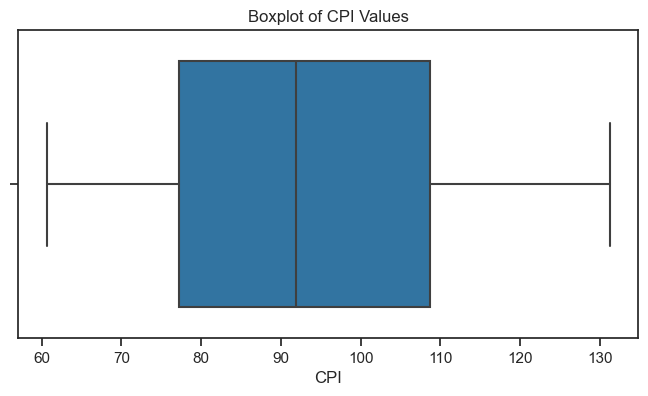

In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['CPI'])
plt.title('Boxplot of CPI Values')
plt.show()

### **1.7 Key Finding**

**Data Cleaning Steps Documented:**
- No missing values found.
- Converted `'Quarter'` strings into quarterly periods.
- Final DataFrame indexed by `Quarter_Period`, containing only numeric CPI values.
- No anomalies detected in CPI beyond expected range based on the boxplot.

## 2. Exploratory Data Analysis (EDA)

**In this section, we will cover:**
1. Visualize the raw CPI time series
2. Decompose the raw CPI into observed, trend, seasonal, and residual components
3. Test for stationarity on the raw CPI (assessing ACF plot + ADF test)
4. Apply first-order differencing to remove trend
5. Re-check stationarity on the first-order differencing (ACF plot and ADF test)
6. Apply seasonal differencing to remove quarterly seasonality
7. Re-check stationarity on the seasonal differencing (ACF plot and ADF test)

### **2.1 Time Series Plot**

In [24]:
y = df_clean['CPI']

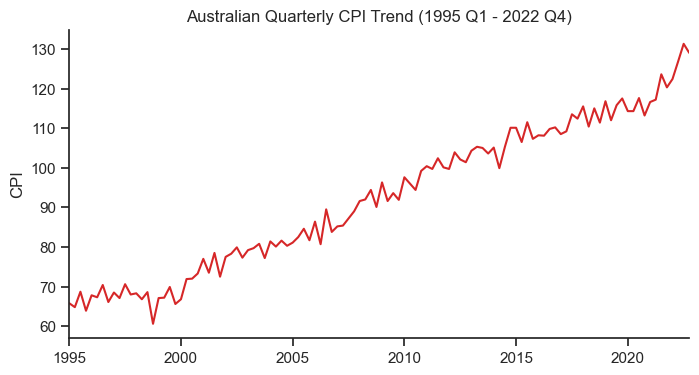

In [25]:
fig, ax= plt.subplots(figsize=(8,4))
y.plot(color=red)
ax.set_xlabel('')
ax.set_ylabel('CPI')
ax.set_title('Australian Quarterly CPI Trend (1995 Q1 - 2022 Q4)')
ax.set_xticks([], minor=True) # I prefer to remove the minor ticks for a cleaner plot
sns.despine()
plt.show()

**Observation:** The CPI shows a clear upward trend from 1995 to 2022, with regular fluctuations suggesting seasonality

### **2.2 Time Series Decomposition**

We decomposed the CPI series into its trend, seasonal, and residual components, using an additive model with period of 4 quarters 

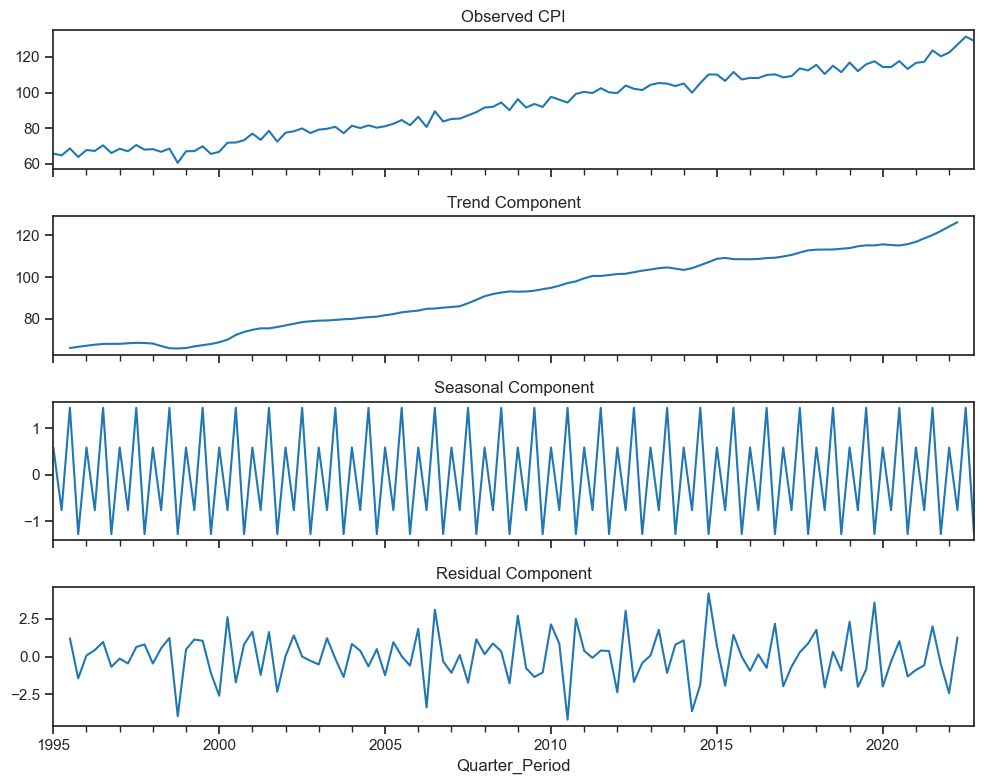

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Decompose on the original PeriodIndex series
decomposition = seasonal_decompose(y, model='additive', period=4)

# 2. Manually plot each component, converting to timestamps 
fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

# Observed
decomposition.observed.to_timestamp().plot(ax=axs[0], title='Observed CPI')

# Trend
decomposition.trend.to_timestamp().plot(ax=axs[1], title='Trend Component')

# Seasonal
decomposition.seasonal.to_timestamp().plot(ax=axs[2], title='Seasonal Component')

# Residual
decomposition.resid.to_timestamp().plot(ax=axs[3], title='Residual Component')

plt.tight_layout()
plt.show()

In [30]:
resid = decomposition.resid.dropna()
print(resid.describe())

count    108.000000
mean      -0.011921
std        1.586528
min       -4.188773
25%       -1.060185
50%        0.056829
75%        0.986227
max        4.194560
Name: resid, dtype: float64


**Interpretation**:
- **Observed CPI:** The top panel shows the raw CPI values from 1995 Q1 to 2022 Q4, plotting quarter by quarter. An increasing trend can be seen approximately from 65 to 130, with small deviations suggesting a repeating seasonal component.
- **Trend Component:** The second panel shows the averaged (smoothed) version of the `Observed CPI` plot. We can see the trend curve slopes upward. But the slope is not perfectly constant, as we can see some fluctuations. 
- **Seasonal Component:** The third panel shows a repeating quarterly pattern after removing the trend effect. 
- **Residual Component:** The bottom panel displays what remains after removing both trend and seasonal effects. Most residuals hover close to zero; this is due to the residual range from approximately -2.5 to 2.5. As the CPI itself rose from about 65 to 130, a $\pm$ 2.5 is relatively small, adding with their mean is very close to zero (-0.01). Due to the residual is approximately homoscedastic, log-transform the series is not required.

**Seasonal (Quarterly) Summary Statistics**

In [33]:
df_clean['Quarter_Num'] = df_clean.index.quarter
seasonal_stats = df_clean.groupby('Quarter_Num')['CPI'].agg(['mean', 'std', 'min', 'max'])
seasonal_stats

,mean,std,min,max
Quarter_Num,,,,
1,92.125000,18.366084,65.8,122.4
2,91.364286,18.258072,64.8,126.8
3,94.200000,18.695910,68.6,131.3
4,92.035714,19.722730,60.6,129.0


### **2.3 Stationary Check Using ACF (Autocorrelation Function) and ADF (Augmented Dickey-Fuller Test)**

We can assess the stationarity by assessing its (sample) ACF plot on the raw CPI. 

<Figure size 800x400 with 0 Axes>

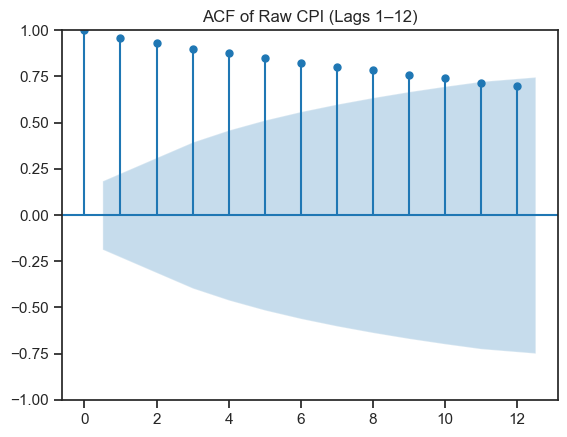

In [36]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8, 4))
plot_acf(df_clean['CPI'], lags=12, alpha=0.05)
plt.title("ACF of Raw CPI (Lags 1–12)")
plt.show()

**Key takeaways:** The ACF plot shows a slow decay (and some points over the confidence band). Thus, this indicates non-stationary and requires further data transformation.

We now assess the PACF (Partial Autocorrelation Function):

<Figure size 800x400 with 0 Axes>

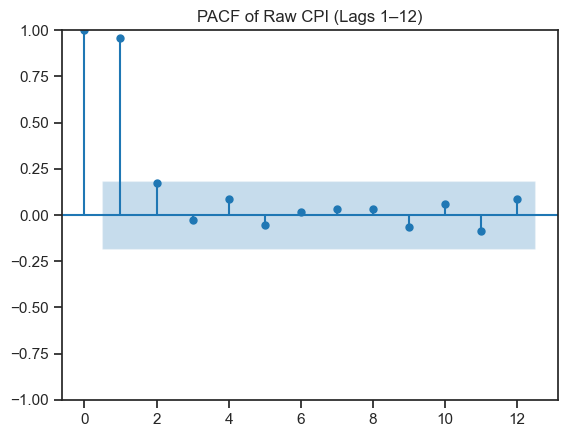

In [39]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(8, 4))
plot_pacf(df_clean['CPI'], lags=12, alpha=0.05)
plt.title("PACF of Raw CPI (Lags 1–12)")
plt.show()

- **Key takeaways:** The PACF has a large spike at lag 1 and then cuts off, that hints at an autoregressive term of order 1, AR(1). 

We now using Augmented Dickey-Fuller to assess stationarity. 

In [42]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df_clean['CPI'])
print("ADF Statistic: {:.4f}".format(adf_result[0]))
print("p-value: {:.4f}".format(adf_result[1]))
for key, crit in adf_result[4].items():
    print("Critical Value ({}): {:.4f}".format(key, crit))

ADF Statistic: 1.0731
p-value: 0.9950
Critical Value (1%): -3.4975
Critical Value (5%): -2.8909
Critical Value (10%): -2.5824


- **Key takeaways:** The ADF p-value > 0.05, this suggests non-stationarity and further data transformation required. 

### **2.4 Data Transformation**

### _**2.4.1 First-Order Differencing To Remove Trend**_

- A p-value from ADF so close to 1. This means that the raw CPI series is strongly non-stationary. We also see in the ACF a slow decay and big spikes at lag = 1 to 10, confirming seasonality.
- Thus, we will now first remove the non-seasonal trend (first-order differencing, d = 1). The first-order differencing subtracts each quarter's CPI from the previous quarter to remove the deterministic trend. 

In [47]:
df_diff = df_clean['CPI'].diff(1).dropna()

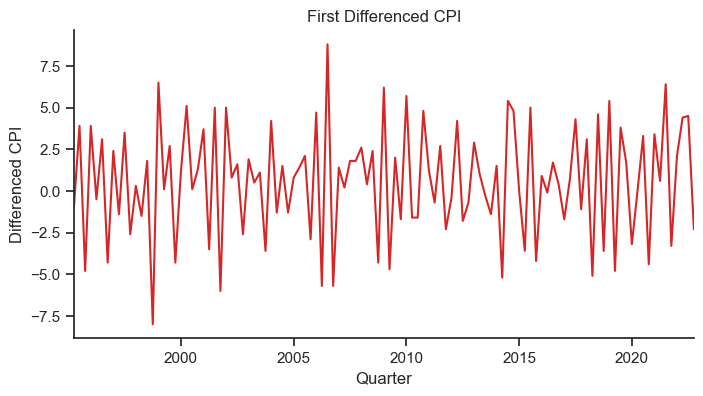

In [48]:
fig, ax= plt.subplots(figsize=(8,4))
df_diff.plot(color=red)
ax.set_xlabel('Quarter')
ax.set_ylabel('Differenced CPI')
ax.set_title('First Differenced CPI')
ax.set_xticks([], minor=True) # I prefer to remove the minor ticks for a cleaner plot
sns.despine()
plt.show()

- **Key Takeaways:** The new plot generated using the the first differenced CPI showed no clear trend compared to upward trend on the raw CPI

We then assessed stationarity using ADF and ACF 

In [51]:
# ADF test on differenced series
adf_diff = adfuller(df_diff)
print("ADF Statistic (diff): {:.4f}".format(adf_diff[0]))
print("p-value (diff): {:.4f}".format(adf_diff[1]))
for key, crit in adf_diff[4].items():
    print("Critical Value ({}): {:.4f}".format(key, crit))

ADF Statistic (diff): -3.2859
p-value (diff): 0.0155
Critical Value (1%): -3.4975
Critical Value (5%): -2.8909
Critical Value (10%): -2.5824


- **Key takeaways:** The ADF p-value is < 0.05 (0.015), indicating that the series is now stationary.

We next observe the ACF plot.

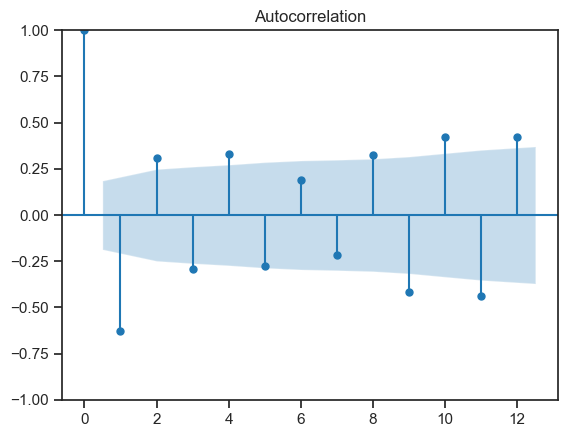

In [54]:
sm.graphics.tsa.plot_acf(df_diff, lags=12, alpha = 0.05)
plt.show()

- **Key takeaways:** The ACF now shows no slow decay like the ACF for the raw CPI. However, the ACF often still shows a large spike in some lags, such as lags = 4, 5, 8, 9, 10, 11, and 12. Thus, there is residual quarterly seasonality that has not been yet removed.

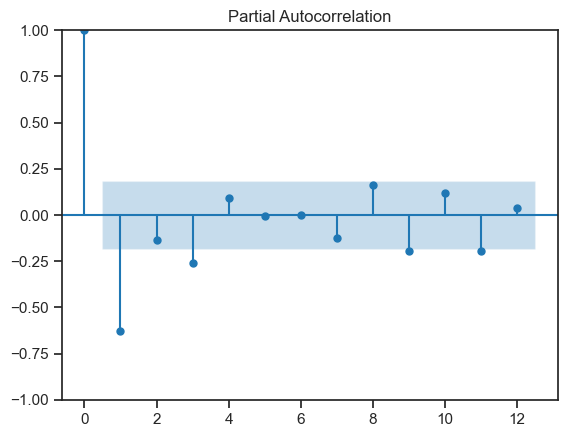

In [56]:
sm.graphics.tsa.plot_pacf(df_diff, lags=12, alpha = 0.05)
plt.show()

- **Key takeaways:** The PACF plot also indicates seasonality as some lags, such as lags = 1, 3, 9, and 11, show the seasonal effect. 

### _**2.4.2 Seasonal Difference To Remove Quarterly Seasonality**_ 

- Although the ADF's p-value from the first-order differencing indicates stationarity, results from the ACF and PCAF plots still suggest seasonality as some lags are over the confidence band.
- Thus, we will take a lag = 4 difference (lag = 4 represents the quarterly seasonal effect) on the first-order differencing (D = 1, s = 4). In other words, we will use double differencing (first-order + seasonal differencing).  

In [60]:
df_sea_diff = df_diff.diff(4).dropna()

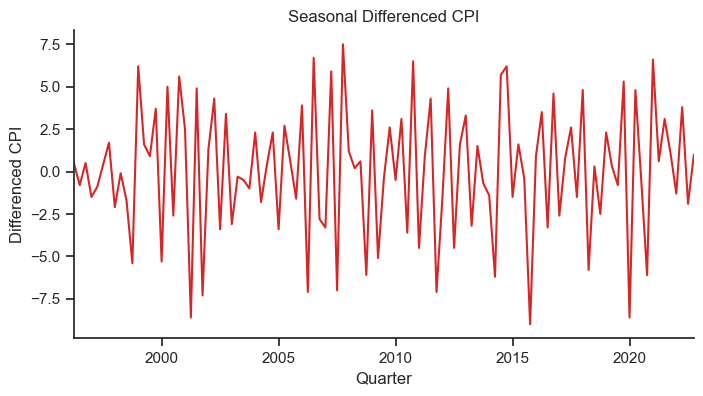

In [61]:
fig, ax= plt.subplots(figsize=(8,4))
df_sea_diff.plot(color=red)
ax.set_xlabel('Quarter')
ax.set_ylabel('Differenced CPI')
ax.set_title('Seasonal Differenced CPI')
ax.set_xticks([], minor=True) # I prefer to remove the minor ticks for a cleaner plot
sns.despine()
plt.show()

- **Key Takeaways:** The new plot generated after first-order + seasonal differencing still doesn't show any trends. 

We then apply ADF and ACF to check for the model stationarity 

In [64]:
adf_sea_diff = adfuller(df_sea_diff)
print("ADF Statistic (seasonal diff): {:.4f}".format(adf_sea_diff[0]))
print("p-value (seasonal diff): {:.4f}".format(adf_sea_diff[1]))
for key, crit in adf_sea_diff[4].items():
    print("Critical Value ({}): {:.4f}".format(key, crit))

ADF Statistic (seasonal diff): -5.3910
p-value (seasonal diff): 0.0000
Critical Value (1%): -3.4989
Critical Value (5%): -2.8915
Critical Value (10%): -2.5828


- **Key Takeaways:** The ADF p-value is effectively 0.00, that confirms stationarity in both trend and seasonal and no further differencing is needed.

We then investigate the ACF plot for the double differencing series. 

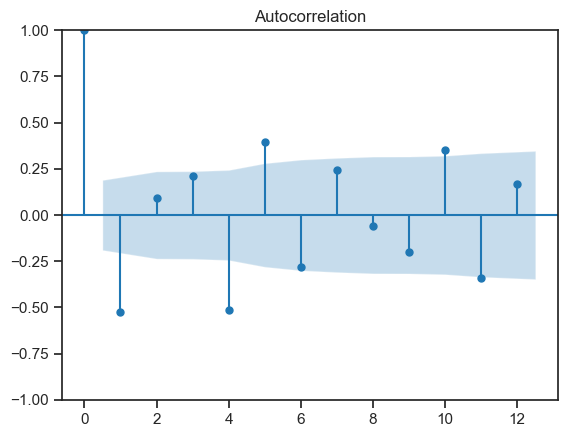

In [67]:
sm.graphics.tsa.plot_acf(df_sea_diff, lags=12, alpha = 0.05)
plt.show()

- **Key Takeaways:** Even though the ADF p-value already indicated stationarity and the double differencing has removed the trend and seasonality, the ACF plot still has some lags that are over the confidence band, such as lags = 1, 4, 5, 10, and 11, this still indicates a seasonal MA. 

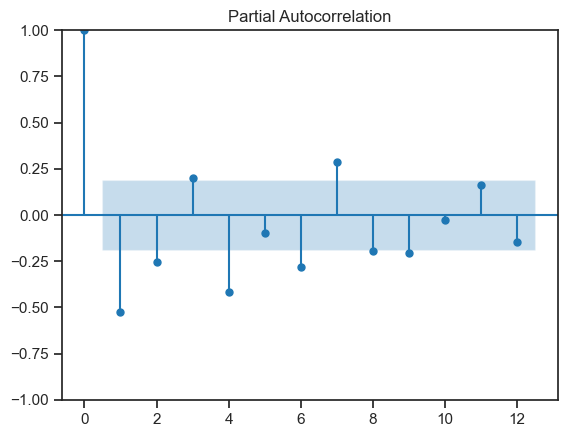

In [69]:
sm.graphics.tsa.plot_pacf(df_sea_diff, lags=12, alpha = 0.05)
plt.show()

- **Key Takeaways:** The PACF plot shows some lags that are over the confidence band, such as lags = 1, 2, 3, 4, 6, 7, 8, and 9. Which still suggesting seasonal AR. 

## 3. Appropriate Analysis and Implementation: Assumptions 

### 3.1 AR/MA/ARMA/ARIMA Model Assumptions

Below is a revised summary of all assumption checks, incorporating the ACF/PACF results after differencing:

1. **Stationarity Check (ADF test and ACF/PACF on the raw series)**  
   - We plotted the ACF of the raw CPI series and observed a slow decay plus a large seasonal spike at lags 4–10 (Section 2.3).  
   - The Augmented Dickey–Fuller (ADF) test on the raw series returned p around 0.995 (> 0.05), confirming non‐stationarity and a clear quarterly seasonal cycle (period = 4).  
   - **Conclusion:** The raw CPI is non‐stationary which contains a quarterly sesonal cycle (period = 4).

2. **Non‐Seasonal Differencing (d = 1)**  
   - To remove the deterministic trend, we applied a first‐order difference:  `df_diff = df_clean['CPI'].diff(1).dropna()`  
   - On `df_diff`, the ADF test returned p‐value around 0.01 (< 0.05), indicating stationarity in the non‐seasonal sense.   
   - The ACF of `df_diff` still exhibited a significant spike at lag 4 (and additional significance at lags 1, 2, 3, 7, 10, 11).  
   - The PACF of `df_diff` showed a large spike at lag 1 (plus smaller but significant spikes at lags 2, 3, 7, 11), suggesting a non‐seasonal AR(1) component once trend is removed.  
   - **Conclusion:** After first differencing (d = 1), the series is nonseasonally stationary but still contains quarterly seasonality.

3. **Seasonal Decomposition (justification for adjustment method)**  
   - We decomposed CPI with `seasonal_decompose(y, model='additive', period=4)` (Section 2.3), which showed a clear repeating quarterly pattern in the “seasonal” component.  
   - This confirms that a seasonal adjustment (either by differencing or by modeling seasonal AR/MA terms) is necessary.  
   - Rather than subtracting the seasonal component directly, we will apply a seasonal difference to remove that repeating cycle.

4. **Seasonal Differencing (D = 1, s = 4)**  
   - We applied a seasonal difference `df_sea_diff` on top of the first difference:  
     `
     df_diff = df_clean['CPI'].diff(1).dropna()
     `
     
     `
     df_sea_diff = df_diff.diff(4).dropna()
     `
   - On `df_sea_diff`, the ADF test returned p of 0.00 (< 0.05), confirming stationarity in both trend and seasonal senses.  
   - The ACF of `df_sea_diff` still showed significant spikes at lags 4, 5, 10, 11 (in addition to lag 1). In particular, the spike at lag 4 implies a seasonal MA(1) component is needed.  
   - The PACF of `df_sea_diff` exhibited significant spikes at lags 1, 2, 3, 4, 6, 7, 8. Interpreting these:  
     - **Lags 1–3:** Nonseasonal AR terms may be required (p could be up to 3).  
     - **Lag 4 (and 8):** Seasonal AR effects—suggesting P could be 1 or 2.  
     - **Lags 6, 7:** These are the near-seasonal echoes.  
   - **Conclusion:** After applying d = 1 and D = 1, the series is stationary. Remaining ACF/PACF spikes indicate candidate AR/MA orders rather than additional differencing.

5. **Summary of Required Model Terms**  
   - **Non‐seasonal differencing:** d = 1 (confirmed by ADF).  
   - **Seasonal differencing:** D = 1, s = 4 (confirmed by ADF and ACF).  
   - **Non‐seasonal AR (p):** Significant PACF spikes at lags 1–3, candidate $p \in {1, 2, 3}$.  
   - **Non‐seasonal MA (q):** ACF of `df_sea_diff` shows significance at lag 1 (and weaker at lag 2), candidate $q \in {1, 2}$.  
   - **Seasonal AR (P):** PACF spikes at lags 4 and 8, candidate $P \in {1, 2}$.  
   - **Seasonal MA (Q):** ACF spike at lag 4, Q = 1.  

All required assumptions checks have been completed. AIC/BIC (and rolling-window CV) on these shortlists of (p,d,q,P,D,Q) is needed to identify the final model.   


## 4. Appropriate Analysis and Implementation: Modelling and Training 

In this section, we build several time-series forecasting models, using window rolling validation and AIC/BIC for hyperparameter selection. We then interpret results and address the original business questions.

Based on the stationarity checks, ADF tests, and ACF/PACF plots carried out in Sections 2 and 3 (EDA and Assumptions), the data exhibits both a significant upward trend and seasonality. After performing first-order differencing and seasonal differencing, the series appears stationary. We will assess the following models:

1. **ARIMA(p,d,q) with Seasonal Component or SARIMA**
    - _**Why a Seasonal ARIMA (SARIMA) Model:**_
      - The ADF test on first-order differencing data gave a p-value around 0.01, indicating stationarity (see Section 2.4.1). However, the ACF and PACF still show the seasonal effect of the series.
      - After applying seasonal difference at lag = 4 (D = 1), the series still became stationary with the p-value of 0 (this also suggests no further differencing is needed). However, after we tried to remove the trend and seasonal effect, the ACF and PACF still showed some significant spikes. This suggests the need for both nonseasonal and seasonal AR/MA components.
      - **Conclusion:**  Because the raw CPI data exhibit a clear nonstationary trend and a strong quarterly cycle, and because ACF/PACF patterns from the first-order differencing and seasonal differencing point to short‐term autocorrelation at lags 1–3 plus seasonal autocorrelation at lag 4, a SARIMA model is a great choice. It removes trend and seasonality via differencing and then uses AR/MA terms to capture any remaining short‐term or seasonal autocorrelation.

2. **Seasonal Random Walk**
   - **Why a Seasonal Random Walk?:**
     - The Seasonal Random Walk will be treated as a naive method, and will mainly be assessed as a forecast benchmark, as this is a very simple model that explicitly incorporates seasonal behavior (by “copying” the observation from the same quarter of the previous year).
     - By using a seasonal random walk as a baseline, we force ourselves to justify the additional complexity of the SARIMA. Thus, before finalizing SARIMA as our "best model", we compare its rolling-window validation MSE to that of the seasonal random walk to ensure SARIMA is justified. 

### **4.1 Seasonal ARIMA Model and Seasonal Random Walk**

In this section we will do the following:
- First we will split the dataset into `training_set` and `test_set`, this will allow us to assess the in-sample and out-of-sample performance. The `test_set` is the last 8 observations. 
- Because the data is quarterly, any SARIMA must explicitly model seasonality with a period of 4 (s = 4). That is, **SARIMA(p,d,q) x (P,D,Q)**.
- We fix $d = 1$ and $D = 1$ based on the stationarity checks above, and search over using AIC/BIC:
    - $p \in {0,1,2,3}$
    - $q \in {0,1,2}$
    - $P \in {0,1,2}$
    - $Q \in {0,1}$
- Then, we make use of window rolling validation (4-steps ahead) to assess in sample MSE, while using seasonal random walk as a benchmark.

In [78]:
n_test = 8
training_set = df_clean.iloc[:-n_test].copy()
testing_set = df_clean.iloc[-n_test:].copy()

This is the training set of the CPI with the size of 104

In [80]:
training_set

,CPI,Quarter_Num
Quarter_Period,,
1995Q1,65.8,1
1995Q2,64.8,2
1995Q3,68.7,3
1995Q4,63.9,4
1996Q1,67.8,1
...,...,...
2019Q4,117.5,4
2020Q1,114.3,1
2020Q2,114.3,2


This is the testing set of the CPI with the size of 8

In [82]:
testing_set

,CPI,Quarter_Num
Quarter_Period,,
2021Q1,116.6,1
2021Q2,117.2,2
2021Q3,123.6,3
2021Q4,120.3,4
2022Q1,122.4,1
2022Q2,126.8,2
2022Q3,131.3,3
2022Q4,129.0,4


In [83]:
print(f"Training set length: {len(training_set)}")
print(f"Test set length:     {len(testing_set)}")
print("Train period:", training_set.index[0], "to", training_set.index[-1])
print("Test period: ", testing_set.index[0], "to", testing_set.index[-1])

Training set length: 104
Test set length:     8
Train period: 1995Q1 to 2020Q4
Test period:  2021Q1 to 2022Q4


- We then utilize the `pmadrima` library to do the grid search of the parameters, with the range of the `p, q, d, P, Q, D` already specified above. For each combination, we fit a SARIMAX model on the `training_set` and record the AIC. We then select the combination with the lowest AIC for further evaluation.

In [85]:
import pmdarima as pm

In [86]:
auto_sarima = pm.auto_arima(
    training_set['CPI'],
    start_p=0, max_p=3,
    start_q=0, max_q=2,
    d=1,
    seasonal=True,
    m=4,
    start_P=0, max_P=2,
    start_Q=0, max_Q=1,
    D = 1,
    information_criterion="aic",
    suppress_warnings=True,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[4]             : AIC=552.757, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[4]             : AIC=498.187, Time=0.02 sec
 ARIMA(0,1,1)(0,1,1)[4]             : AIC=457.284, Time=0.03 sec
 ARIMA(0,1,1)(0,1,0)[4]             : AIC=inf, Time=0.04 sec
 ARIMA(0,1,1)(1,1,1)[4]             : AIC=458.339, Time=0.04 sec
 ARIMA(0,1,1)(1,1,0)[4]             : AIC=488.490, Time=0.02 sec
 ARIMA(0,1,0)(0,1,1)[4]             : AIC=491.275, Time=0.02 sec
 ARIMA(1,1,1)(0,1,1)[4]             : AIC=458.819, Time=0.04 sec
 ARIMA(0,1,2)(0,1,1)[4]             : AIC=458.789, Time=0.05 sec
 ARIMA(1,1,0)(0,1,1)[4]             : AIC=466.341, Time=0.02 sec
 ARIMA(1,1,2)(0,1,1)[4]             : AIC=460.584, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[4] intercept   : AIC=459.268, Time=0.06 sec

Best model:  ARIMA(0,1,1)(0,1,1)[4]          
Total fit time: 0.439 seconds


- From the above combinations (and also 2 model summary below), we can see that the best model has the:
  - Best non-seasonal part `ARIMA(p,d,q)` with the `p = 0, d = 1, q = 1`.
  - Best seasonal part `(P,D,Q)[S]` with the `P = 0, D = 1, Q = 1, S = 4`.
- This is because:
  - The `ARIMA(0,1,1)` was set, because after a first-order difference, the upward trend, the ACF/PACF did not show strong lag = 1, lag = 2, or lag = 3 autoregressive spikes. Instead, a single MA(1), or the moving average of order 1 best captured any remaining short-term shock, or in the other words, current value of the series is influenced by the current random shock and the effect of the previous random shock.
  - We also used `(0,1,1)[4]` to remove the quarterly cycle (seasonal difference D = 1 at lag = 4, or S = 4), and then model any "same quarter one-year-ago" forecasting error with seasonal MA(1) (Q = 1).
  - The `p = P = 0` means that the non-seasonal AR term and seasonal AR term are both not needed. `p = 0` means that after differencing out the trend, there is not enough evidence that the last quarter's differenced value explains the current value, while `P = 0` suggests that the last year's seasonally differenced CPI does not help explain the current quarter's seasonally differenced CPI.
  - The `q = Q = 1` means that the non-seasonal MA term and seasonal MA term are both needed. `q = 1` means that each quarter's change is partly adjusted by the previous quarter's error. While `Q = 1` means that each quarter's seasonally differenced value is partly adjusted by the last year's same-quarter error.

In [88]:
print(auto_sarima.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  104
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 4)   Log Likelihood                -225.642
Date:                           Thu, 05 Jun 2025   AIC                            457.284
Time:                                   20:45:49   BIC                            465.069
Sample:                               03-31-1995   HQIC                           460.434
                                    - 12-31-2020                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6310      0.082     -7.668      0.000      -0.792      -0.470
ma.S.L4       -0.8798      0.076    -11.538

- Based on the model summary:
  - We can see that `ma.L1` and `ma.S.L4` are both significant with p-value < 0.05, this justifies keeping 1 non-seasonal MA and 1 seasonal MA in the model.
  - The coefficient `ma.L1` of -0.6310 implies the model corrects for about 63% of last quarter's error in the current quarter's differenced prediction.
  - The coefficient `ma.S.L4` of -0.8798 implies the model corrects for 88% of the same quarter error in the previous year.
  - The diagnostic tests:
    - Ljung-Box(L1) with p = 0.61 suggest no remaining autocorrelation in residuals
    - Heteroskedasticity with p = 0.29 suggests no sign of volatility clustering or changing variance.
    - Skew = 0.25 and Kurtosis 3.59 which indicate a slight right skew and fat tail, but not large enough to violate normality.
  - From the diagnostics tests, we can conclude that the residuals are effectively white noise (no aurocorrelation, no heteroskedasticity, and roughly normal). This means that nothing more needs to be added (no AR terms, no higher-order MA terms, etc).

- Next we store the best order for the non-seasonal and seasonal parameters in `best_order` and `best_seasonal` variables. We will use these value to fit the model(s) in the next section.

In [91]:
best_order = auto_sarima.order
best_seasonal = auto_sarima.seasonal_order

print("AIC‐selected non‐seasonal (p,d,q):", best_order)
print("AIC‐selected seasonal  (P,D,Q,m):", best_seasonal)
print("AIC =", auto_sarima.aic(), "BIC =", auto_sarima.bic())

AIC‐selected non‐seasonal (p,d,q): (0, 1, 1)
AIC‐selected seasonal  (P,D,Q,m): (0, 1, 1, 4)
AIC = 457.28370704656845 BIC = 465.0690665969722


- We then use the rolling window validation of the SARIMA model (and naive seasonal random walk) with these configs:
  - `h = 4` as we want to make a four-quarters ahead forecast (or one yearr into the future). Stakeholders may think of this approach as "Where will the CPI be one year from now?".
  - `seasonal_period = 4` as the data has an annual cycle every four quarters.
  - `start = 8` ensures that there are at least 8 quarters of data available for both first-order differencing and seasonal differencing.
  - The rolling window validation will do the following:
    - For each i from 8 to N - 3 (where N is the size of the `training_set`), this means that we stop rolling when i = 100:
      - Stored the actual value.
      - Fit the SARIMA(0,1,1)(0,1,1)[4] only on the data through time i - 1
      - Conducted 4-step ahead forecast, and its 95% confidence interval
      - Simultaneously record the naive seasonal random walk forecast.
    - After that we aligned all actuals and forecasts in the dataframe `df_val`.
    - Computed the rolling mean squared error for the SARIMA and seasonal random walk by using the test error formula provided, with the N in the MSE formula indicated the number of rolling-window iterations (which is 100 - 8 + 1 = 93 iterations), as stored in `df_val` variable.

In [93]:
h = 4
seasonal_period = 4
start = 8

pred_sarima = []
lower_sarima = []
upper_sarima = []
pred_rw4 = []
actual  = []

for i in range(start, len(training_set) - (h - 1)):
    # Actual CPI at time i+(h-1)
    actual.append(training_set['CPI'].iloc[i + h - 1])

    # Fit the selected SARIMA on ts up to i−1
    train_slice = training_set['CPI'].iloc[:i]
    training_sarima = pm.ARIMA(
        order = best_order,
        seasonal_order = best_seasonal,
        suppress_warnings=True
    ).fit(train_slice)

    # Forecast h=4 steps ahead
    fc, conf_int = training_sarima.predict(
        n_periods= h,
        return_conf_int= True,
        alpha= 0.05
    )
    # take the last (4‐step‐ahead) forecast + its CI
    pred_sarima.append(fc[-1])
    lower_sarima.append(conf_int[-1, 0])
    upper_sarima.append(conf_int[-1, 1])

    # Seasonal‐RW: 
    pred_rw4.append(df_clean['CPI'].iloc[i + h - 1 - seasonal_period])

# Build DataFrame of results
validation_index = training_set['CPI'].index[h - 1:]  # drop first h−1 = 3 quarters
df_val = pd.DataFrame({
    "Actual CPI": actual,
    "SARIMA (h=4)": pred_sarima,
    "SARIMA Lower 95% CI": lower_sarima,
    "SARIMA Upper 95% CI": upper_sarima,
    "Seasonal-RW (h=4)": pred_rw4
}, index=validation_index[start:])

# Show the first few rows
print("\nRolling‐window comparison:")
print(df_val)

# Compute rolling MSE for each
mse_sarima = np.mean((df_val["SARIMA (h=4)"] - df_val["Actual CPI"])**2)
mse_rw4    = np.mean((df_val["Seasonal-RW (h=4)"] - df_val["Actual CPI"])**2)

print(f"\nRolling 4‐step MSE (SARIMA): {mse_sarima:.4f}")
print(f"Rolling 4‐step MSE (Seasonal RW): {mse_rw4:.4f}")


Rolling‐window comparison:
                Actual CPI  SARIMA (h=4)  SARIMA Lower 95% CI  \
Quarter_Period                                                  
1997Q4                68.0     68.090394            67.355207   
1998Q1                68.3     68.339199            67.522690   
1998Q2                66.8     65.990231            64.809023   
1998Q3                68.6     69.136524            68.089962   
1998Q4                60.6     69.874738            65.797744   
...                    ...           ...                  ...   
2019Q4               117.5    114.998982           109.650486   
2020Q1               114.3    118.225326           112.925733   
2020Q2               114.3    115.500719           110.185395   
2020Q3               117.6    118.277864           112.984493   
2020Q4               113.2    118.456239           113.172797   

                SARIMA Upper 95% CI  Seasonal-RW (h=4)  
Quarter_Period                                          
1997Q4      

- **Key takeaways:** After the rolling window validation, the MSE for the SARIMA model is around 12.99. While the MSE for the Seasonal Random Walk (naive) is around 13.57. This suggests that the SARIMA's predictions for the 1 year ahead (4 quarters) were closer to the true CPI values than the Seasonal Random Walk model, in which the model simply just repeats the last year's same quarter observation.
- These observations mean the SARIMA not only leverages the year-ago value (as what Seasonal Random Walk does) but also corrects for short-term shocks via its non-seasonal MA order 1 (as what Seasonal Random Walk doesn't do). The fact that the SARIMA's MSE is lower than the naive approach indicates that the additional complexity of the model improves one-year-ahead (4 quarters) CPI accuracy. 

We then plot the time series plot including the actual training set, seasonal random walk forecast, and the SARIMA with the 95% confidence interval. 

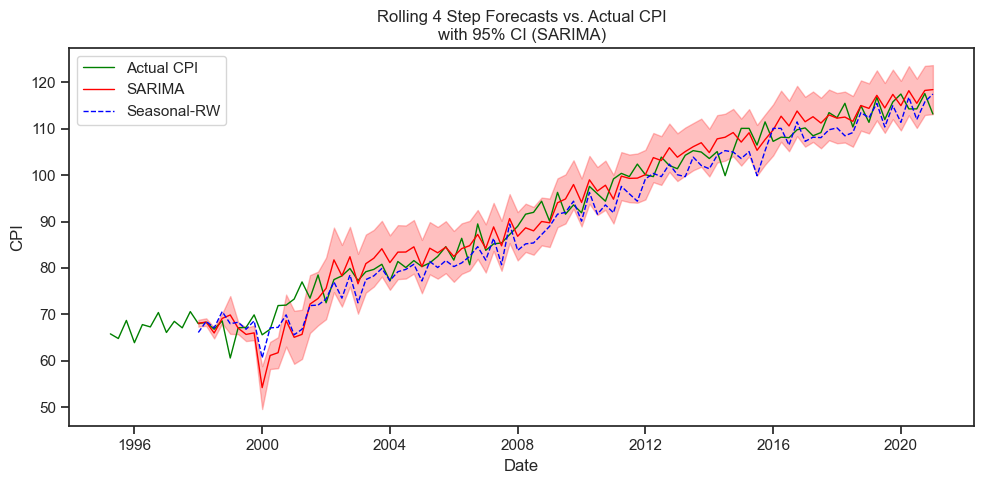

In [96]:
plt.figure(figsize=(10, 5))

# Plot actual CPI
plt.plot(training_set['CPI'].index.to_timestamp(how="end"), training_set["CPI"], label="Actual CPI", color="green", linewidth=1)

# Plot SARIMA forecasts
plt.plot(df_val.index.to_timestamp(how="end"), df_val["SARIMA (h=4)"], label="SARIMA", color="red", linewidth=1)

# Shaded 95% CI around SARIMA
plt.fill_between(
    df_val.index.to_timestamp(how="end"),
    df_val["SARIMA Lower 95% CI"],
    df_val["SARIMA Upper 95% CI"],
    color="red",
    alpha=0.25
)

# Plot Seasonal-RW forecasts
plt.plot(df_val.index.to_timestamp(how="end"), df_val["Seasonal-RW (h=4)"], label="Seasonal-RW", linestyle="--", color="blue", linewidth=1)


plt.xlabel("Date")
plt.ylabel("CPI")
plt.title("Rolling 4 Step Forecasts vs. Actual CPI\nwith 95% CI (SARIMA)")
plt.legend()
plt.tight_layout()
plt.show()

- From the plot we can see that, the SARIMA able to predict most of the actual CPI value, as most actual CPI values falls within the SARIMA forecast confidence intervals.

## 5. Appropriate Analysis and Implementation: Final Model

### **5.1 Fitting the SARIMA model on the testing set**

Section 4 has explained the reason why SARIMA is a great model to use in this dataset compared to the naive approach. We will fit the SARIMA model with the best parameters to forecast on the `testing_set`. We will assess out-of-sample performance in this section. The section includes:
- Fit the final SARIMA model on all available training data
- Extract in-sample residuals and prepare for diagnostics:
  - `resid_insample` will pull out the vector of in-sample residuals from the fitted SARIMA model.
  - `insample_index`, `resid_series`, because differencing used up the first few observations, the residual array is shorter than the original `training_set`, this makes sure that each residual gets a matching quarter label.
  - Trim the first 5 residuals: This is because the SARIMA model does one non-seasonal differencing and one seasonal differencing, these differencing use up the observation. In addition, the seasonal MA or nonseasonal MA are both required for the past errors, which means that the first few fitted residuals rely on the data that no longer exist after differencing or by initial guess.
  - Thus, trimming the first 5 residuals will make the diagnostic tests (e.g, checking ACF of residuals, etc.) are reliable.
- Generate out-of-sample forecasts (with 95% confidence interval).
- Compute out-of-sample MSE by comparing the test values forecast with the actual values.
- Export out-of-sample forecasts to CSV file as a `CPI_forecast.csv`

First five in‐sample residuals:
Quarter_Period
1996Q2    0.497662
1996Q3   -0.577217
1996Q4    0.170778
1997Q1   -1.449970
1997Q2   -1.332971
            ...   
2019Q4    2.911154
2020Q1   -3.686202
2020Q2   -0.578177
2020Q3    0.017173
2020Q4   -3.323086
Freq: Q-DEC, Length: 99, dtype: float64
---Out‐of‐Sample (Test) Performance---
SARIMA Test MSE: 46.2525
SARIMA Test RMSE: 6.8009
Two‐column CSV saved to 'CPI_forecast.csv':
8 rows of test‐set forecasts:
                Actual CPI  SARIMA Forecast  SARIMA Lower CI  SARIMA Upper CI
Quarter_Period                                                               
2021Q1               116.6       116.962191       112.484486       121.439896
2021Q2               117.2       115.424150       110.652485       120.195816
2021Q3               123.6       118.389651       113.341112       123.438190
2021Q4               120.3       116.925019       111.614021       122.236017
2022Q1               122.4       118.842095       113.098412       124.58

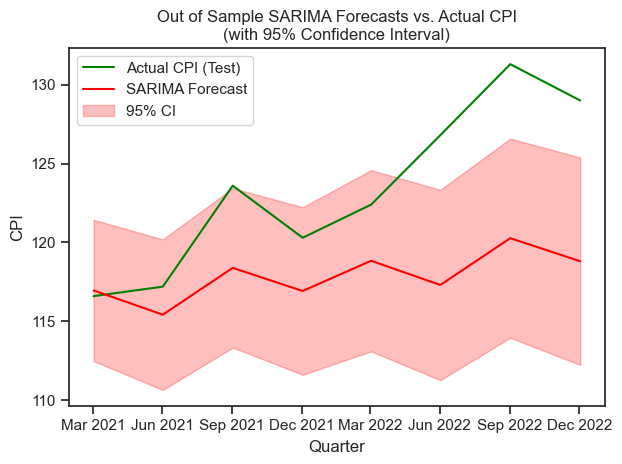

In [101]:
final_sarima = pm.ARIMA(
    order = best_order,
    seasonal_order= best_seasonal
).fit(training_set["CPI"])

resid_insample = final_sarima.resid()  

insample_index = training_set.index[len(training_set) - len(resid_insample):]  
resid_series = pd.Series(resid_insample, index=insample_index)
resid_trimmed = resid_series.iloc[5:]

# Quick look at the first few residuals
print("First five in‐sample residuals:")
print(resid_trimmed)


final_fc, final_conf = final_sarima.predict(
    n_periods = n_test,
    return_conf_int = True,
    alpha = 0.05
)

# Separate out lower‐ and upper‐bounds for convenience

sarima_fc = final_fc     # point forecast on CPI‐level
sarima_lower = final_conf[:, 0]  # 95% CI lower on CPI‐level
sarima_upper = final_conf[:, 1] 

# Actual test values
actual_test = testing_set["CPI"].values


# compute out=of-sample MSE
mse_sarima_test = np.mean((actual_test - sarima_fc)**2)

print("---Out‐of‐Sample (Test) Performance---")
print(f"SARIMA Test MSE: {mse_sarima_test:.4f}")
print(f"SARIMA Test RMSE: {np.sqrt(mse_sarima_test):.4f}")

# export out-of-sanmple forecast to csv
df_test_forecasts = pd.DataFrame({
    "Actual CPI": actual_test,
    "SARIMA Forecast": sarima_fc,
    "SARIMA Lower CI": sarima_lower,
    "SARIMA Upper CI": sarima_upper
}, index=testing_set.index)

df_simple = df_test_forecasts[["SARIMA Forecast"]].reset_index()
df_simple.columns = ["Quarter", "CPI"]

# Ensures the CSV shows “2023Q1” instead of some timestamp.
if isinstance(df_simple["Quarter"].dtype, pd.PeriodDtype):
    df_simple["Quarter"] = df_simple["Quarter"].astype(str)

# export only these two columns to CSV (no index column):
output_path_simple = "CPI_forecast.csv"
df_simple.to_csv(output_path_simple, index=False)

print(f"Two‐column CSV saved to '{output_path_simple}':")

print("8 rows of test‐set forecasts:")
print(df_test_forecasts)


plt.plot(
    df_test_forecasts.index.to_timestamp(how='end'),
    df_test_forecasts["Actual CPI"],
    label = "Actual CPI (Test)",
    color = "green",
    linewidth=1.5
)

# Plot SARIMA Forecast 
plt.plot(
    df_test_forecasts.index.to_timestamp(how='end'),
    df_test_forecasts["SARIMA Forecast"],
    label = "SARIMA Forecast",
    color = "red",
    linewidth=1.5
)

# Shade the 95% CI
plt.fill_between(
    df_test_forecasts.index.to_timestamp(how='end'),
    df_test_forecasts["SARIMA Lower CI"],
    df_test_forecasts["SARIMA Upper CI"],
    color = "red",
    alpha = 0.25,
    label = "95% CI"
)

plt.xticks(
    df_test_forecasts.index,
    df_test_forecasts.index.strftime('%b %Y'),
)

plt.xlabel("Quarter")
plt.ylabel("CPI")
plt.title("Out of Sample SARIMA Forecasts vs. Actual CPI\n(with 95% Confidence Interval)")
plt.legend()
plt.tight_layout()
plt.show()

- **Key Takeaways:** When we forecast against the actual CPI values, MSE is about 46.25. The MSE formula for this case is the same as the test error formula provided with 8 observations. In addition, the RMSE (root mean square) of around 6.80 means that two-year-ahead forecasts tend to be off by about $\pm$ 6.8 CPI units.
- From the plot generated with the SARIMA forecast, actual testing CPI, and the 95% confidence interval, we can see that although some actual CPI is under the 95% confidence interval, some quarters, such as Jun 2022, Sep 2022 and Dec 2022 are over the forecast confidence interval. 

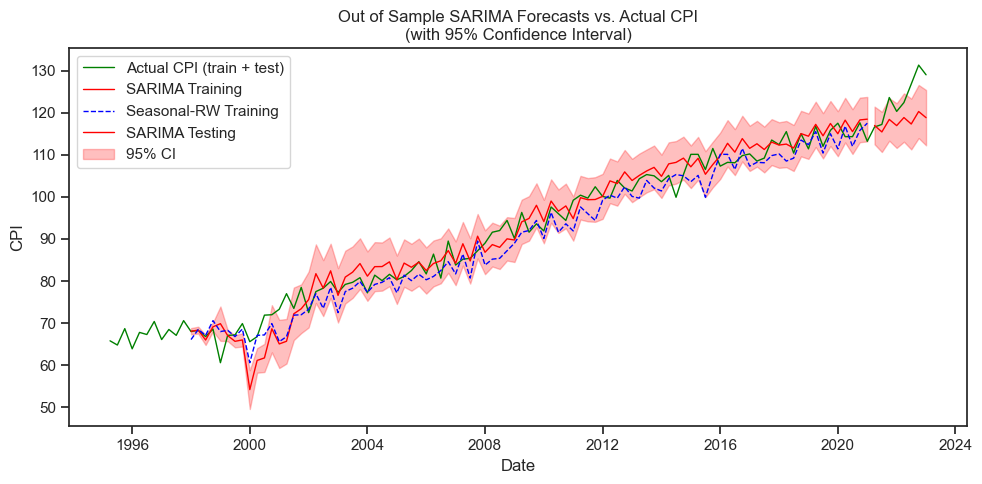

In [103]:
plt.figure(figsize=(10, 5))

# (1) Plot actual CPI
plt.plot(df_clean['CPI'].index.to_timestamp(how="end"), df_clean["CPI"], label="Actual CPI (train + test)", color="green", linewidth=1)
#plt.plot(df_val.index.to_timestamp(), df_val["Actual CPI"], label="Actual CPI", color="black")
# (2) Plot SARIMA forecasts
plt.plot(df_val.index.to_timestamp(how="end"), df_val["SARIMA (h=4)"], label="SARIMA Training", color="red", linewidth=1)

# (3) Shaded 95% CI around SARIMA
plt.fill_between(
    df_val.index.to_timestamp(how="end"),
    df_val["SARIMA Lower 95% CI"],
    df_val["SARIMA Upper 95% CI"],
    color="red",
    alpha=0.25
)

# (4) Plot Seasonal-RW forecasts
plt.plot(df_val.index.to_timestamp(how="end"), df_val["Seasonal-RW (h=4)"], label="Seasonal-RW Training", linestyle="--", color="blue", linewidth=1)



# (b) Plot SARIMA Forecast (solid blue)
plt.plot(
    df_test_forecasts.index.to_timestamp(how="end"),
    df_test_forecasts["SARIMA Forecast"],
    label   = "SARIMA Testing",
    color   = "red",
    linewidth=1
)

# (c) Shade the 95% CI
plt.fill_between(
    df_test_forecasts.index.to_timestamp(how="end"),
    df_test_forecasts["SARIMA Lower CI"],
    df_test_forecasts["SARIMA Upper CI"],
    color   = "red",
    alpha   = 0.25,
    label   = "95% CI"
)

plt.xlabel("Date")
plt.ylabel("CPI")
plt.title("Out of Sample SARIMA Forecasts vs. Actual CPI\n(with 95% Confidence Interval)")
plt.legend()
plt.tight_layout()
plt.show()

- Adding the training set model forecasts, we can see the overall SARIMA forecast with other models as well. However, the gap between the training forecasts and testing forecasts can be explained by the 3-months gap between the quarters, in this case, between the `2020Q4` and `2021Q1`, so the plot is normal. 

### **5.2 Model Diagnostics**

In this model diagnostics part, we will do the following:
- Plot the in-sample residuals of the final SARIMA model
- Plot the ACF/PACF of the in-sample residual of the final SARIMA model.
- Plot the QQ plot and the Histogram to check the normality assumptions.

First we want to see if the residuals over time hover randomly around zero, with no obvious trend or changing variability. 

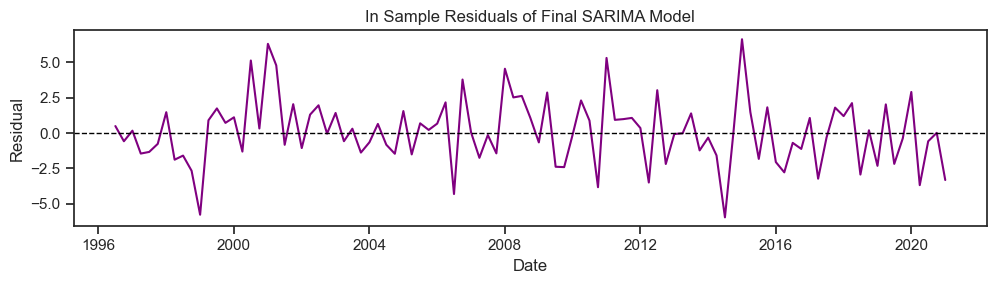

In [108]:
plt.figure(figsize=(10, 3))
plt.plot(resid_trimmed.index.to_timestamp(how="end"), resid_trimmed.values, color="purple")
plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.title("In Sample Residuals of Final SARIMA Model")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

-**Key Takeaways:** The residuals over time seem to hover around zero, and no obvious trend or changing variability observed. 

Next we will observe the ACF plot to see if no significant spikes are observed.

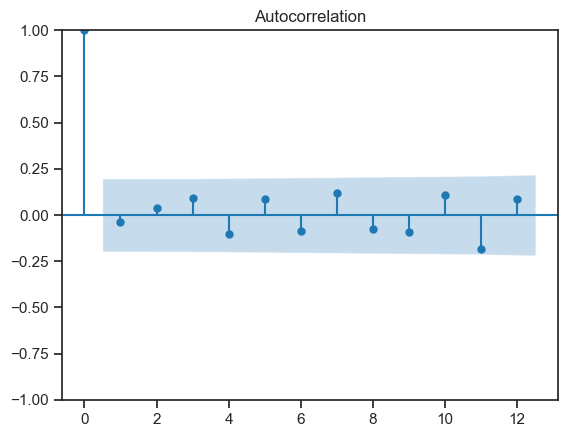

In [111]:
sm.graphics.tsa.plot_acf(resid_trimmed, lags=12, alpha = 0.05)
plt.show()

-**Key Takeaways:** The ACF plot has all autocorrelations except lag = 0 lie within the 95% confidence bands

Next we will observe the PACF plot to see if no significant spikes are observed.

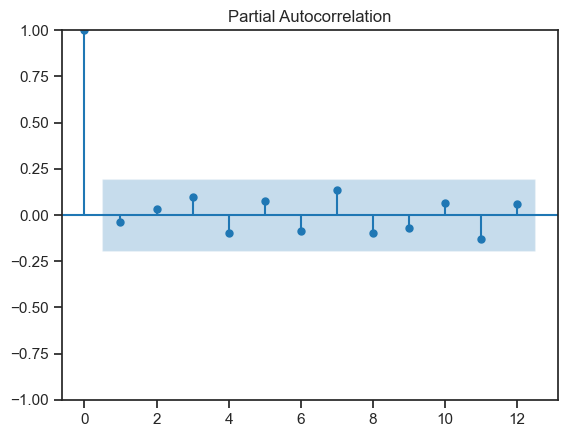

In [114]:
sm.graphics.tsa.plot_pacf(resid_trimmed, lags=12, alpha = 0.05)
plt.show()

-**Key Takeaways:** Similar to the ACF, the partial autocorrelation indicate no significant bands.

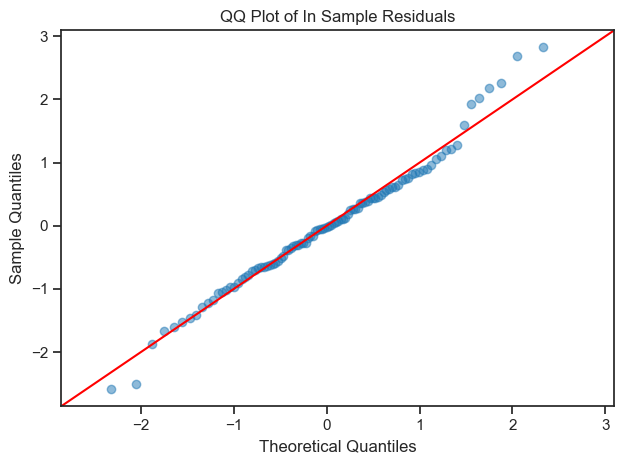

In [116]:
fig = sm.qqplot(resid_trimmed, line='45', fit=True, alpha=0.5)
plt.title("QQ Plot of In Sample Residuals")
plt.tight_layout()
plt.show()

-**Key Takeaways:** The QQ plot has the residuals follow roughly the straight-line relationship with the theoretical normal quantiles. 

We then plot the histogram of the residual, with the normal curve as a baseline

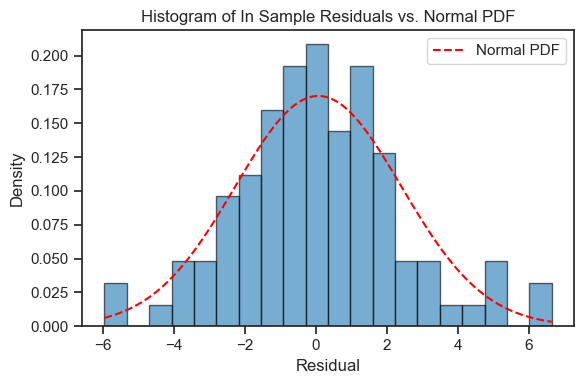

In [119]:
plt.figure(figsize=(6, 4))
plt.hist(resid_trimmed, bins=20, density=True, edgecolor='k', alpha=0.6)
mu, sigma = resid_trimmed.mean(), resid_trimmed.std()
x_vals = np.linspace(resid_trimmed.min(), resid_trimmed.max(), 100)
pdf_vals = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_vals - mu)/sigma)**2)
plt.plot(x_vals, pdf_vals, 'r--', linewidth=1.5, label="Normal PDF")
plt.title("Histogram of In Sample Residuals vs. Normal PDF")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

-**Key Takeaways:** As the QQ plot already showed the residual follows normality, the histogram also show normality (when compared with the normal pdf curve).

- **Conclusion:** As the SARIMA model passes all the diagnostic checks, this means that the trimmed residuals:
  - Show no significant autocorrelation in their ACF/PACF.
  - Appear approximately normal (in QQ plot and histogram).
  - Exhibit no heteroskedasticity (as the residual and time plot show roughly constant spread).
- This means that:
  - The two MA(1) terms have effectively removed both trend/seasonality.
  - Forecast intervals are reliable (under normality and homoskedastic errors).
  - No additional AR or MA needed, as no significant spikes presence in ACF and PACF
  - The final model (SARIMA) can be treated as suitable for forecasting.

## 6. Interpretation, Discussion, and Conclusions

### **6.1 Interpretation of Results** 

### _6.1.1 Out-of-Sample Accuracy (MSE and RMSE)_

- Over the eight‐quarter testing set period (2021 Q1–2022 Q4), SARIMA(0, 1, 1)(0, 1, 1)[4] achieved a test‐set MSE of 46.25, corresponding to an RMSE of approximately 6.8 CPI points. Thus, stakeholders should therefore expect, on average, two‐year‐ahead CPI forecasts to be off by about $\pm$ 6.8 index points.

### _6.1.2 Confidence Interval Coverage_

- When we overlay the 95 % confidence bands on the actual CPI values from 2021 Q1 through 2022 Q4, most quarters fall within the interval. However, three quarters lie outside their 95 % bands:
    - 2022 Q2 (June 2022) lies above the upper bound,
    - 2022 Q3 (September 2022) lies above the upper bound,
    - 2022 Q4 (December 2022) lies above the upper bound.
- This means that the model has underestimated the uncertainty during volatile periods. From the actual CPI plot, we can see a sudden increase in CPI from 2021 Q2 to 2022 Q4, this sudden change hasn't been considered in the model. 

### _6.1.3 In-sample Diagnostic Checks_

- **Reisdual Plot:** After trimming the first 5 boundary residual, the in-sample residuals hovers randomly around 0 with no visible trend or changing spread. 
- **ACF/PACF of Residuals:** Neither ACF or PACF showed significant spikes. 
- **Normality and Homoskedasticity:** The QQ-Plot and Histogram have showed the evidence of homoskedasticity and normality of the residual.
- In conclusion, `SARIMA(0,1,1)(0,1,1)[4]` has captured all patterns, in terms of trend, seasonality, etc., effectively leaving white-noise errors. 

### **6.2 Discussion**

### _6.2.1 Addressing the Original Business Question_

- The main goal of the assignment is to forecast the CPI from 2 years ahead, 8 quarters from March 2023 to December 2024. Fitting the `SARIMA(0,1,1)(0,1,1)[4]` on data up to December 2022, and then calling `predict(n_periods = 8)` or `n_periods` as the size of that `test_CPI` dataset. 

### _6.2.2 Why SARIMA(0,1,1)(0,1,1)[4] Appropriate?_

- **Data Characteristics:** Quarterly CPI exhibits a clear upward trend and a strong yearly seasonal pattern. Differencing once (d = 1) removed the trend; taking a seasonal difference at lag 4 (D = 1) removed the annual seasonality.
- **Model Selection (AIC + Rolling Validation):** A grid search over `(p,d,q)×(P,D,Q)` confirmed `(0, 1, 1) × (0, 1, 1)[4]` minimizes AIC. A rolling‐window comparison (1-year-ahead) showed SARIMA outperformed a simple seasonal naive benchmark.
- **Diagnostics:** Residual ACF/PACF, normality observations using plots all passed, indicating approximately normal errors, and constant variance.

### _6.2.3 Model Limitations_

- **Purely Univariate:** The model uses only historical CPI, without the consideration of some major "shock" events such as pandemics, housing crises, etc., which influence the CPI rather than its past CPI alone. This limits the model's ability to forecast the CPI if "these" events happen, such as the model poorly forecasting the CPI from 2021 Q1 to 2022 Q4 as the actual CPI has a sudden increase between 2021 Q2 and 2022 Q4.
- **Stationarity Assumptions:** SARIMA assumes the model to be stationary after the data has been differenced. However, if the CPI values in the future shift (e.g., permanently higher CPI expectations), that assumption may not hold anymore.
- **Parameter Stability:** The same reason for the `Stationarity Assumptions` above, if there are permanenly higher CPI expectations, then the parameters may be outdates. This require the SARIMA to re-estimate regularly.

### **6.3 Conclusion**

- Our `SARIMA(0,1,1)(0,1,1)[4]`, a model chosen via AIC and justified by clear ACF/PACF patterns successfully captures CPI’s trend and annual seasonality, leaving residuals that pass diagnostics checks. When forecasting the eight quarters from 2023 Q1 through 2024 Q4, the batch RMSE is approximately 6.8 CPI points, reflecting the average error across horizons 1–8. Although most actual values lie within the 95 % confidence bands, three quarters (2022 Q2, 2022 Q3, and 2022 Q4) fell outside, indicating underestimation during periods of increasing volatility. Limitations include its univariate nature, the homoskedasticity assumption (which underestimates uncertainty in volatile periods), and the potential for invalidation of the stationarity assumption.
- We recommend using this model for routine re‐estimating the model if diagnostics checks fail or if real‐time volatile periods happen.

## 7. Applying the Model for the `CPI_test.csv` dataset

In [ ]:
CPI_test = pd.read_csv("CPI_test.csv")


# YOUR CODE HERE
CPI_test

In [ ]:
CPI_test['Date'] = pd.to_datetime(CPI_test['Quarter'], format='%b-%y')
CPI_test['Quarter_Period'] = CPI_test['Date'].dt.to_period('Q')
CPI_test.set_index('Quarter_Period', inplace=True)
CPI_clean = CPI_test[['CPI']].copy()
CPI_clean

In [ ]:
# Train the model on the whole CPI_train dataset 
test_sarima = pm.ARIMA(
    order = best_order,
    seasonal_order= best_seasonal
).fit(df_clean["CPI"])


test_fc, test_conf = test_sarima.predict(
    n_periods = 8,
    return_conf_int = True,
    alpha = 0.05
)

# Separate out lower‐ and upper‐bounds for convenience

cpi_fc = test_fc     # point forecast on CPI‐level
test_lower = test_conf[:, 0]  # 95% CI lower on CPI‐level
test_upper = test_conf[:, 1] 

# Actual test values
actual_test_CPI = CPI_clean["CPI"].values


# compute MSE
mse_sarima_CPI = np.mean((actual_test_CPI - cpi_fc)**2)

print("---CPI Testing Performance---")
print(f"SARIMA Test MSE: {mse_sarima_CPI:.4f}")
print(f"SARIMA Test RMSE: {np.sqrt(mse_sarima_CPI):.4f}")


cpi_test_forecasts = pd.DataFrame({
    "Actual CPI": actual_test_CPI,
    "SARIMA Forecast": cpi_fc,
    "SARIMA Lower CI": test_lower,
    "SARIMA Upper CI": test_upper
}, index=CPI_clean.index)


df_simple_cpi = cpi_test_forecasts[["SARIMA Forecast"]].reset_index()
df_simple_cpi.columns = ["Quarter", "CPI"]

# Ensures the CSV shows “2023Q1” instead of some timestamp.
if isinstance(df_simple_cpi["Quarter"].dtype, pd.PeriodDtype):
    df_simple_cpi["Quarter"] = df_simple_cpi["Quarter"].astype(str)

# export only these two columns to CSV (no index column):
output_path_cpi = "CPI_test_forecast.csv"
df_simple_cpi.to_csv(output_path_cpi, index=False)

print(f"Two‐column CSV of the CPI_test saved to '{output_path_cpi}':")

print("8 rows of test‐set forecasts:")
print(cpi_test_forecasts)


plt.plot(
    cpi_test_forecasts.index.to_timestamp(how='end'),
    cpi_test_forecasts["Actual CPI"],
    label = "Actual CPI (Test)",
    color = "green",
    linewidth=1.5
)

# Plot SARIMA Forecast 
plt.plot(
    cpi_test_forecasts.index.to_timestamp(how='end'),
    cpi_test_forecasts["SARIMA Forecast"],
    label = "SARIMA Forecast",
    color = "red",
    linewidth=1.5
)

# Shade the 95% CI
plt.fill_between(
    cpi_test_forecasts.index.to_timestamp(how='end'),
    cpi_test_forecasts["SARIMA Lower CI"],
    cpi_test_forecasts["SARIMA Upper CI"],
    color = "red",
    alpha = 0.25,
    label = "95% CI"
)

plt.xticks(
    cpi_test_forecasts.index,
    cpi_test_forecasts.index.strftime('%b %Y'),
)

plt.xlabel("Quarter")
plt.ylabel("CPI")
plt.title("Testing SARIMA Forecasts vs. Actual CPI\n(with 95% Confidence Interval)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
test_error = mse_sarima_CPI
print(test_error)